In [2]:
# jax ecosystem
import jax

jax.config.update("jax_platform_name", "gpu")
jax.config.update("jax_enable_x64", True)
print(jax.local_devices()[0].device_kind)

from jax import numpy as np, tree as jtu
import zodiax as zdx
from zodiax.optimisation import sgd, adam
import amigo
import dorito

# other helpful libraries
import numpy
import os
import astropy

# matplotlib ecosystem
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots  # to use matplotlib style "science"

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

NVIDIA GeForce RTX 2080 Ti


/home/max/code/amigo/src/amigo/optical_models.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg


In [6]:
from socket import gethostname

if gethostname() == "glinton":
    path = "/media/morgana1/snert/max/"
elif gethostname() == "AJQ4YHQH9TX":
    path = "/Volumes/morgana1/snert/max/"
else:
    path = "/fred/oz440/max/"

source_name = "HD135344B"
data_path = os.path.join(path, f"data/JWST/{source_name}/calslope/")
uncal_path = os.path.join(path, f"data/JWST/{source_name}/uncal/")
amigo_cache = os.path.join(path, "data/amigo_files/")

cache = os.path.join(amigo_cache, "v_0.0.10/")
output_path = os.path.join(amigo_cache, f"outputs/{source_name}/")

EXP_TYPE = "NIS_AMI"
FILTERS = [
    "F480M",
    "F430M",
    "F380M",
    # "F277W",
]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)


# Loading in data

In [7]:
files = sorted(
    file_fn(data_path), key=lambda hdu: hdu[0].header.get("EXPMID", float("inf"))
)
sci_files = []
cal_files = []

for file in files:

    # manual bad pixel correction
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[71, 22] = 1
    file["BADPIX"].data[65, 41] = 1
    file["BADPIX"].data[35, 70] = 1
    file["BADPIX"].data[70, 55] = 1
    file["BADPIX"].data[5, 5] = 1
    file["BADPIX"].data[-4, 37] = 1
    file["BADPIX"].data[51, 27] = 1
    file["BADPIX"].data[28, 18] = 1
    file["BADPIX"].data[32, 10] = 1

    file["BADPIX"].data[:, :3] = 1
    file["BADPIX"].data[:, -3:] = 1
    file["BADPIX"].data[:3, :] = 1
    file["BADPIX"].data[-3:, :] = 1

    # if file[0].header["TARGPROP"] == "TD-PDS-70":
    #     # file["BADPIX"].data[36:66, :25] = 1  # BACKGROUND STAR?
    #     file["BADPIX"].data[17, 70] = 1
    #     file["BADPIX"].data[19, 53] = 1
    #     file["BADPIX"].data[5, 22] = 1
    #     file["BADPIX"].data[19, 41] = 1
    #     # file["BADPIX"].data[:66, :25] = 1  # BACKGROUND STAR?
    #     file["BADPIX"].data[76, 45] = 1
    #     file["BADPIX"].data[59, 30] = 1

    if not bool(file[0].header["IS_PSF"]):
        sci_files.append(file)
    elif bool(file[0].header["IS_PSF"]):
        # file[0].header["TARGPROP"] = "HD 228337"
        cal_files.append(file)
    else:
        print(f"Unkown target: {file[0].header['TARGPROP']}")

# dorito.misc.truncate_files(sci_files, 30)

In [8]:
from astropy.time import Time

t0 = Time(0, format="mjd")
for file in files:
    h = file[0].header
    t = Time(h["EXPMID"], format="mjd")

    if t.ymdhms[2] != t0.ymdhms[2]:
        print("\n" + 30 * "-" + "\n")

    print(
        f'{h["TARGPROP"]} {h["FILTER"]}, Dither {h["PATT_NUM"]}/{h["NUMDTHPT"]}, Roll {h["ROLL_REF"]:.1f}deg, {h["XPOSURE"] / 60:.1f}min, {t.iso}, Groups: {h["NGROUPS"]}, Ints: {h["NINTS"]}, PWCPOS {h["PWCPOS"]}'
    )
    t0 = t


------------------------------

TD-HD-135344B F480M, Dither 1/1, Roll 288.7deg, 9.6min, 2023-02-24 17:58:36.805, Groups: 3, Ints: 2541, PWCPOS 205.02333099999976
TD-HD-135344B F380M, Dither 1/1, Roll 288.7deg, 8.9min, 2023-02-24 18:13:14.303, Groups: 3, Ints: 2351, PWCPOS 205.023331
TD-HD-135344B F430M, Dither 1/1, Roll 288.7deg, 6.6min, 2023-02-24 18:26:19.144, Groups: 2, Ints: 2625, PWCPOS 205.02333100000027
TD-CAL-HD-123991 F480M, Dither 1/1, Roll 302.2deg, 15.2min, 2023-02-24 19:20:07.785, Groups: 29, Ints: 418, PWCPOS 205.0233309999992
TD-CAL-HD-123991 F430M, Dither 1/1, Roll 302.2deg, 12.7min, 2023-02-24 19:36:30.612, Groups: 20, Ints: 507, PWCPOS 205.0233309999996
TD-CAL-HD-123991 F380M, Dither 1/1, Roll 302.2deg, 7.7min, 2023-02-24 19:49:00.589, Groups: 10, Ints: 612, PWCPOS 205.02333100000027


## Building the model

In [6]:
load_dict = lambda x: np.load(f"{x}", allow_pickle=True).item()  # helper function

# just two science exposures and one calibrator for this demo
sci_exps = [dorito.model_fits.PointResolvedFit(file) for file in sci_files]
# cal_exps = [amigo.model_fits.PointFit(file) for file in cal_files]
# exps = sci_exps + cal_exps
# exps = cal_exps
exps = sci_exps

# building the model
source_size = 81  # pixels
basis, window = dorito.bases.inscribed_annulus_basis(source_size, iterations=1)
init_dist = np.ones((source_size, source_size)) / window.sum()

model = dorito.models.TransformedResolvedModel(
    exposures=exps,
    optics=amigo.optical_models.AMIOptics(),
    detector=amigo.detector_models.LinearDetector(),
    ramp_model=amigo.ramp_models.NonLinearRamp(),
    read=amigo.read_models.ReadModel(),
    state=load_dict(cache + "calibration.npy"),
    basis=basis,
    window=window,
    param_initers={"contrast": 0.04, "distribution": init_dist},
)

model.params["aberrations"] = load_dict("files/HD135344B_CALFIT.npy")["aberrations"]

File 01242_003_02_03_1
Star TD-HD-135344B
Filter F480M
nints 2541
ngroups 3



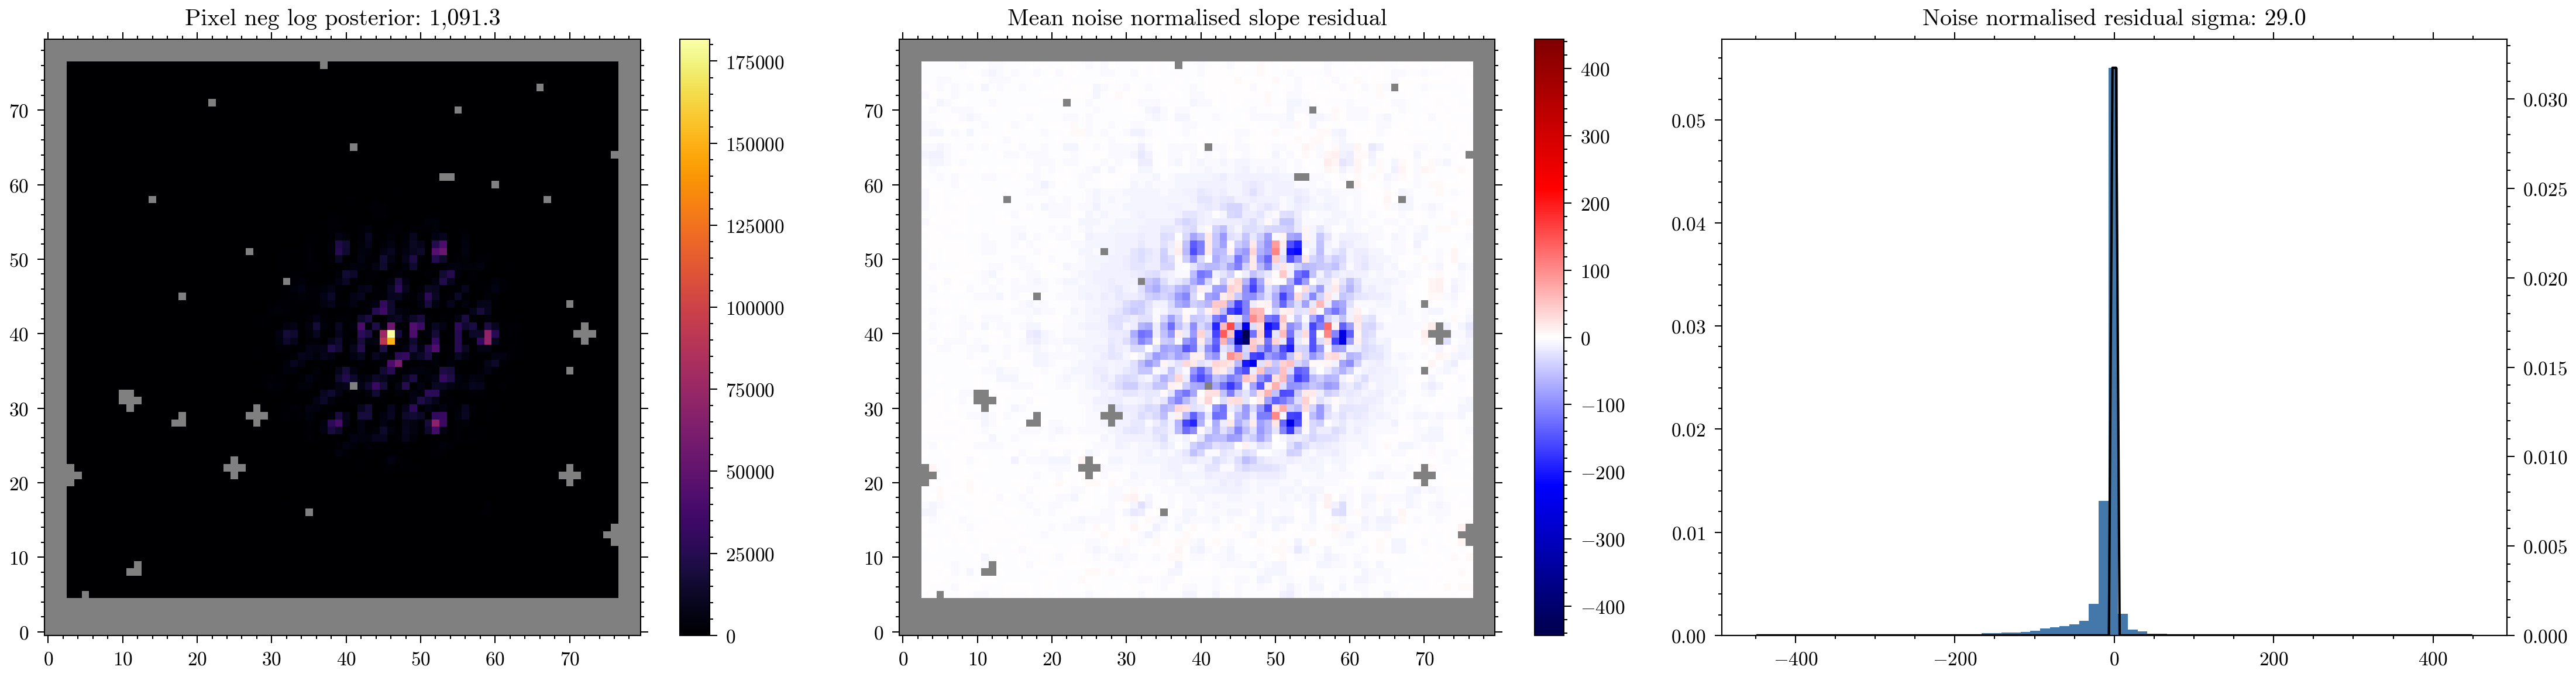

In [7]:
for exp in exps:
    exp.print_summary()
    amigo.plotting.summarise_fit(model, exp, residuals=False)

## Optimisation Stage 1: Gradient Descent

In [9]:
pos_keys = []
spc_keys = []
flx_keys = []
for exp in exps:
    if not exp.calibrator:
        spc_keys.append(exp.map_param("spectra"))
        pos_keys.append(exp.map_param("positions"))


from jax_gaussian import gaussian_filter

sig = 0.25


def norm_fn(model_params, args):
    params = model_params.params

    # NOTE: This normalisation won't work for an arbitrary basis!
    if "log_dist" in params.keys():
        for k, log_dist in params["log_dist"].items():
            # basis = args["basis"]
            # window = args["window"]
            distribution = 10**log_dist
            # distribution = 10 ** basis.from_basis(log_dist) * window
            # distribution = gaussian_filter(distribution, sigma=sig)
            # distribution = distribution.at[args["windown't"]].set(1e-16)
            # distribution += 1e-16 * ((window + 1) % 2)
            log_dist = np.log10(distribution / distribution.sum())
            # log_dist = basis.to_basis(log_dist)
            params["log_dist"][k] = log_dist

    if "spectra" in params.keys():
        spectra = jax.tree.map(
            lambda x: np.clip(x, a_min=-0.8, a_max=0.8), params["spectra"]
        )
        params["spectra"] = spectra

    return model_params.set("params", params), args


pscale = lambda model: model.optics.psf_pixel_scale / model.optics.oversample

In [26]:
n_epoch = 200

config = {
    "positions": sgd(3e-1, 0),
    "fluxes": sgd(2e-1, 0),
    # "aberrations": sgd(2e-2, 4),
    "spectra": sgd(4e-1, 8),
    "log_dist": adam(5e-2, 20),
    # "log_dist": adam(5e-1, 30),
    # "contrast": adam(2e-2, 15),
    # "log_dist": adam(5e-2, 0),
    # "fluxes": sgd(2e-2, 0),
}


def grad_fn(model, grads, args):

    # Reduce spectra gradients for the science exposures
    # if "spectra" in config.keys():
    #     grads = grads.multiply(spc_keys, 0.3)

    # if "fluxes" in config.keys():
    #     grads = grads.multiply(flx_keys, 0.01)
    return grads, args


args = {
    "reg_dict": {
        # "ME": (5e-2, dorito.stats.ME),
        # "TV": (1e-2, dorito.stats.TV),
        # "TV": (1e-2, dorito.stats.TV),
    },
    "source_id": "TD",
    # "basis": basis,
    # "window": window,
}

trainer = amigo.fitting.Trainer(
    loss_fn=dorito.stats.ramp_regularised_loss_fn,
    # norm_fn=norm_fn,
    # grad_fn=grad_fn,
    cache=os.path.join(amigo_cache, "fishers/"),
)

print("Populating fishers...")
trainer = trainer.populate_fishers(
    model,
    exps,
    hessians=load_dict(cache + "jacobians.npy")["hessian"],
    parameters=[p for p in config.keys() if p not in ["log_dist", "contrast"]],
)

print("Number of exposures: ", len(exps))

# Train the model
result = trainer.train(
    model=model,
    optimisers=config,
    epochs=n_epoch,
    batches=exps,
    args=args,
)

Populating fishers...
Number of exposures:  1


  0%|          | 0/200 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 1,092.57
Estimated run time: 0:01:23
Full Time: 0:01:38
Final Loss: 14.49


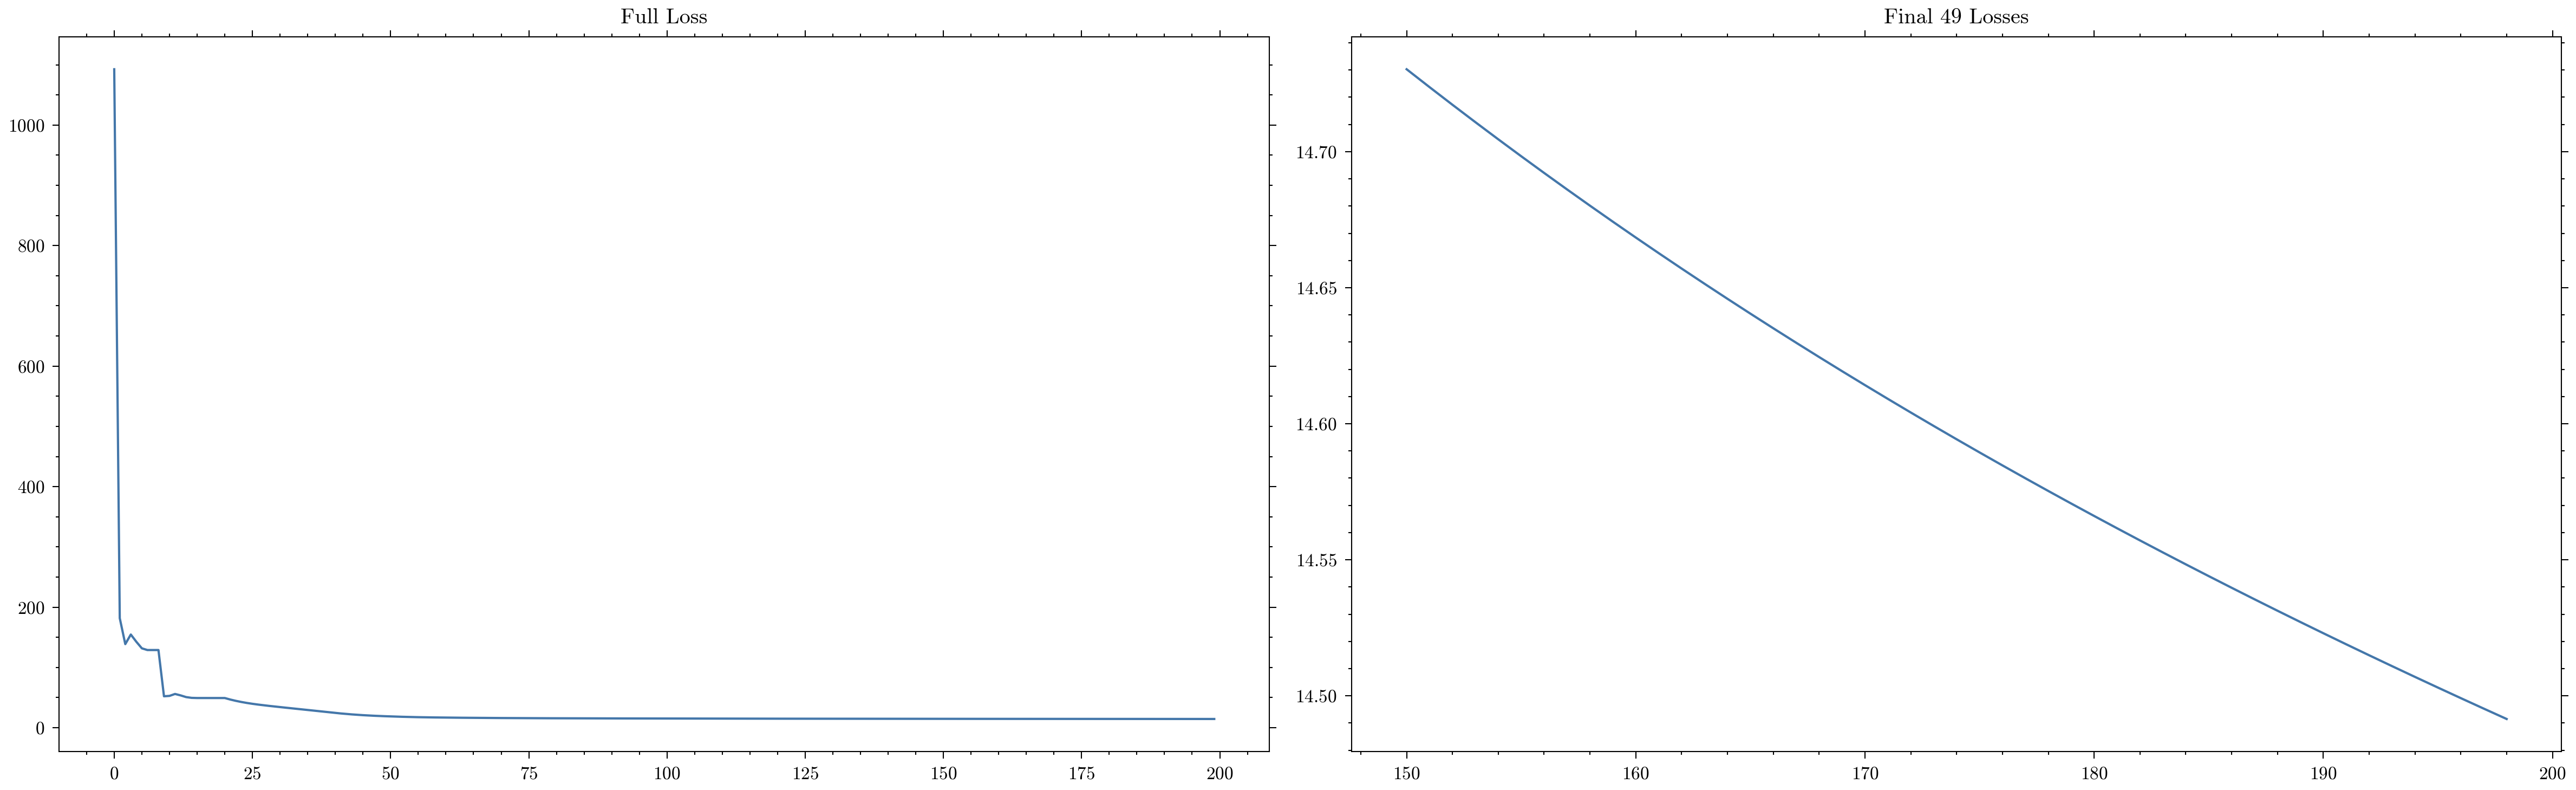

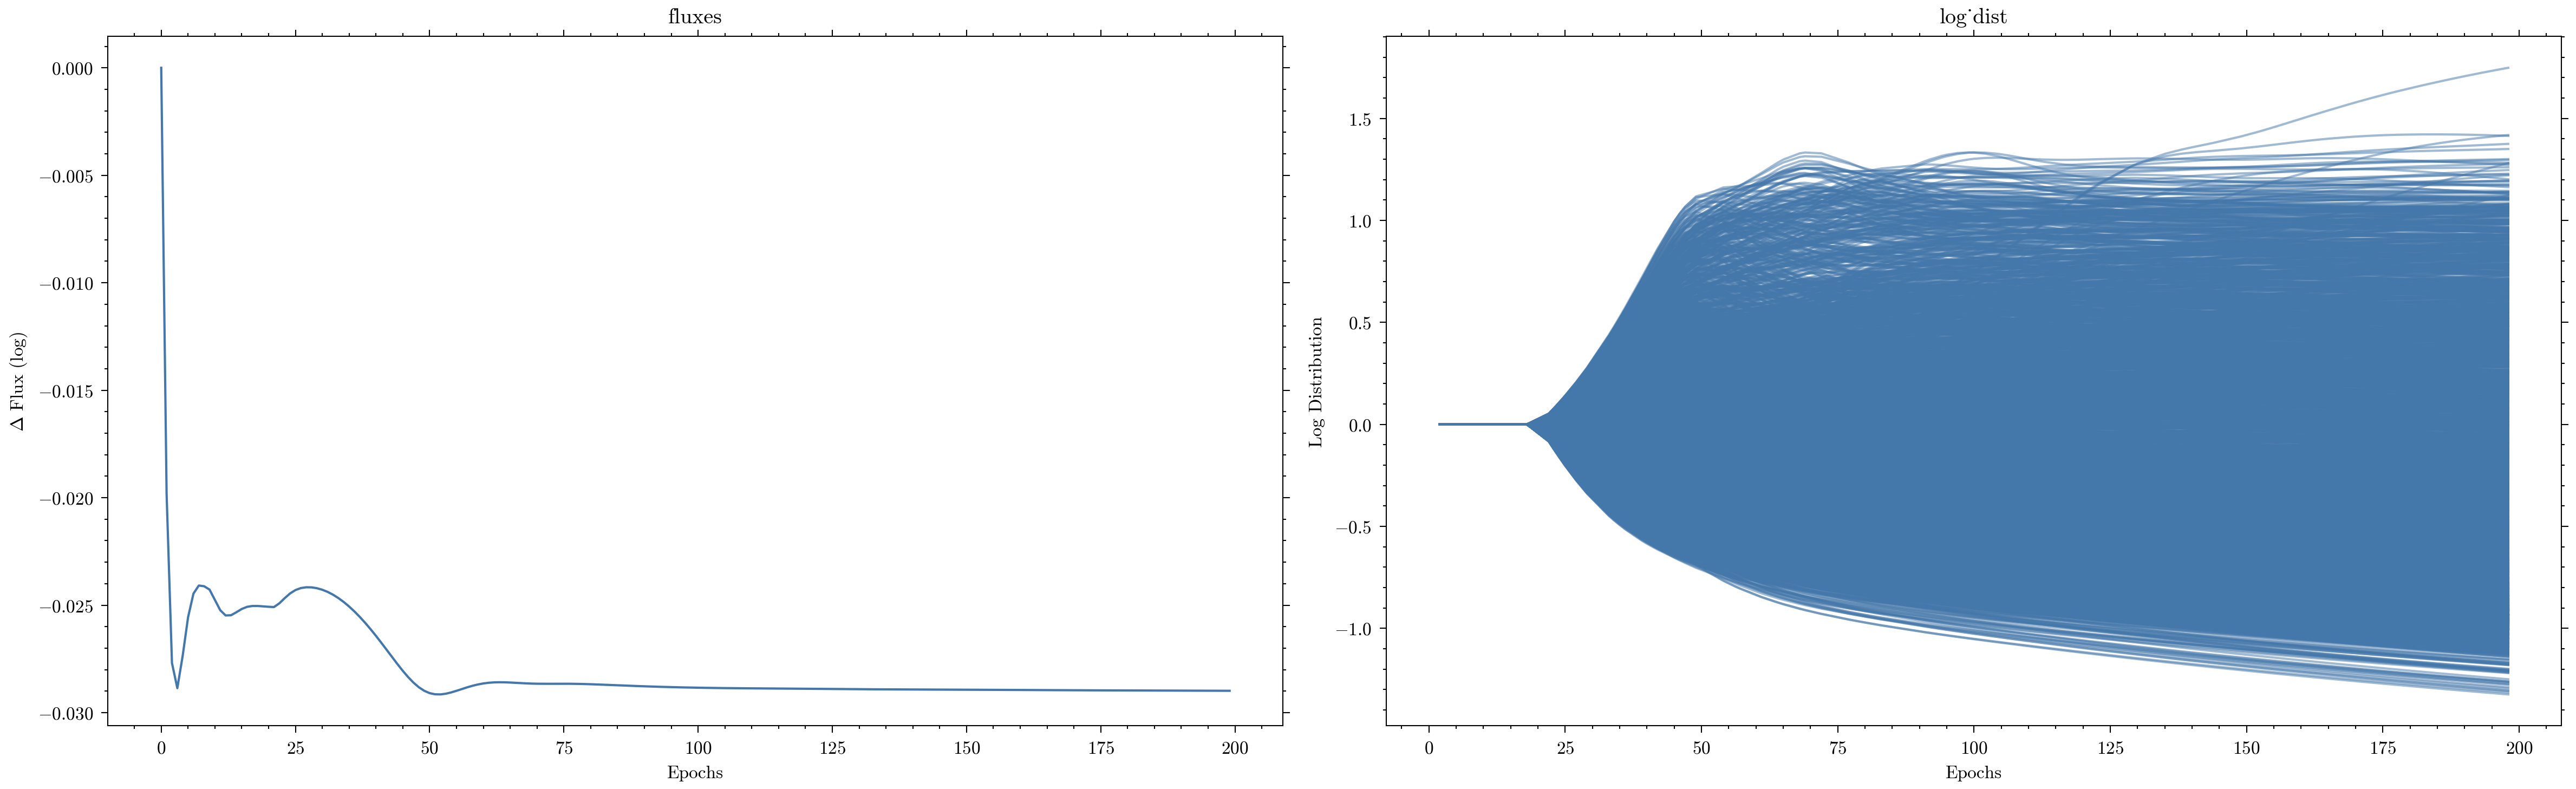

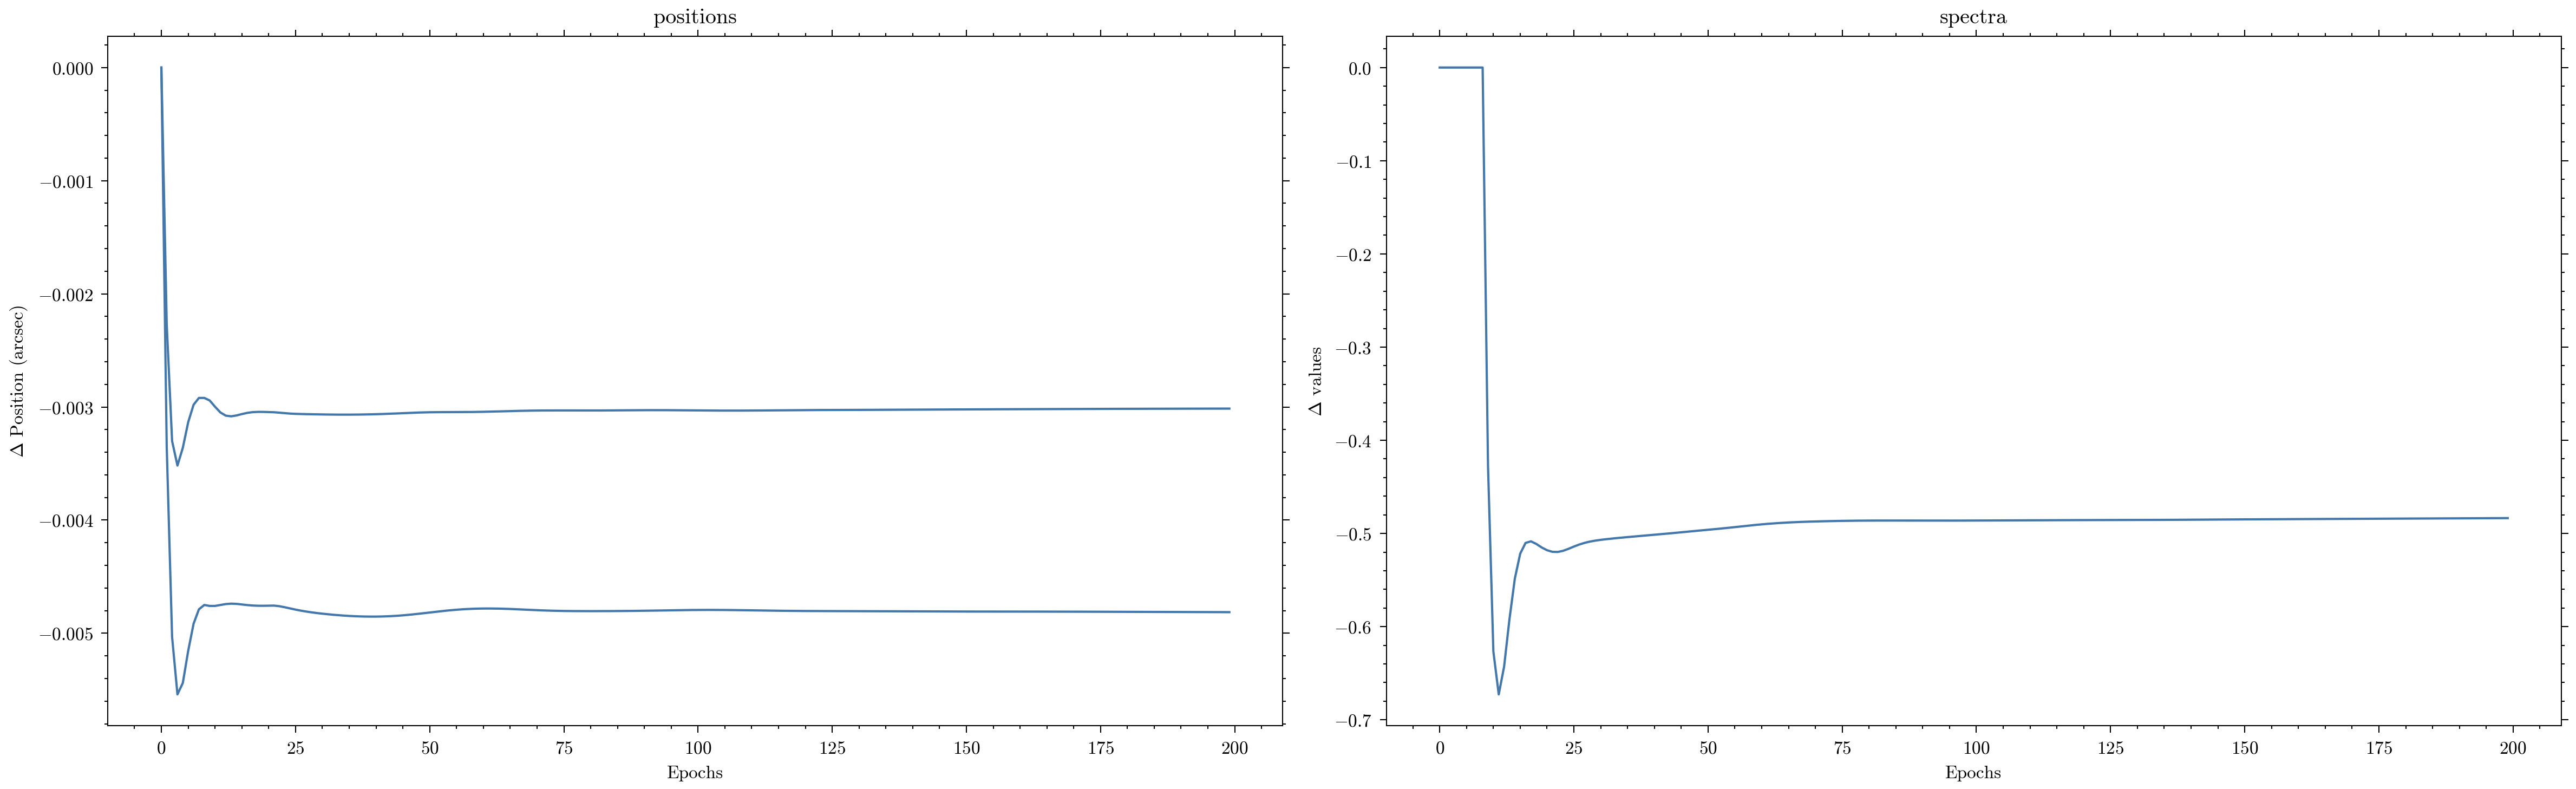

File 01242_003_02_03_1
Star TD-HD-135344B
Filter F480M
nints 2541
ngroups 3



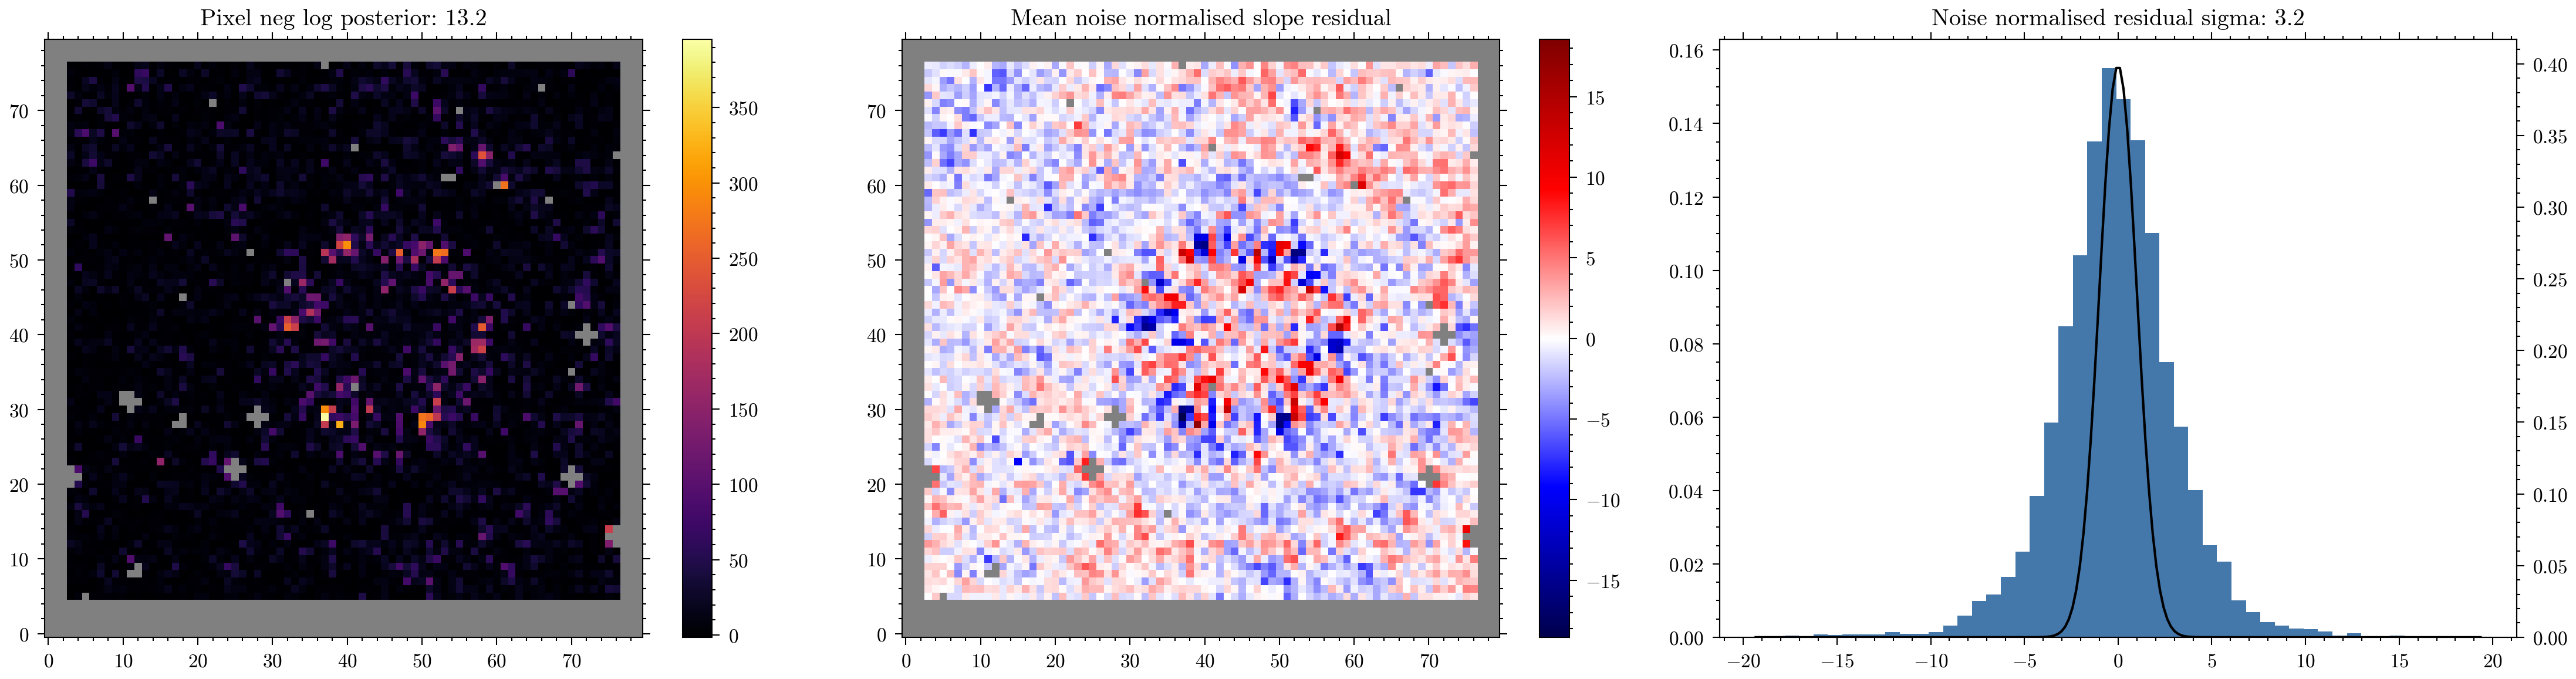

In [27]:
amigo.plotting.plot_losses(result.losses[0], start=int(n_epoch * 0.75))
amigo.plotting.plot(result.history)

for exp in exps:
    exp.print_summary()
    amigo.plotting.summarise_fit(result.model, exp)

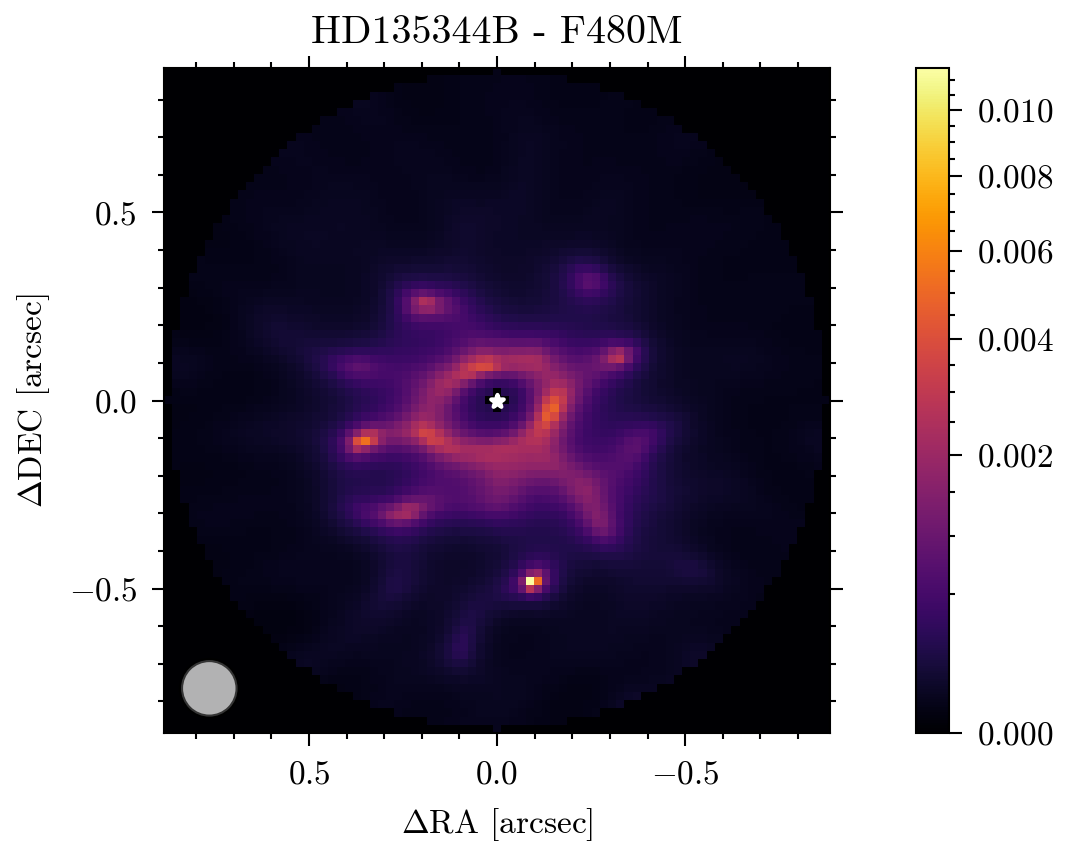

In [28]:
from dLux import utils as dlu

# np.save("files/pds70_abs.npy", result.model.params["aberrations"], allow_pickle=True)


def eff_wavel(model, filt):
    wavels, weights = model.filters[filt]
    return np.dot(wavels, weights)


result_model = result.model
optics_diameter = 6.603464  # JWST aperture diameter in meters

for exp in exps:

    if exp.calibrator:
        continue
    dist = result_model.get_distribution(exp, rotate=False)
    fig, ax = plt.subplots(figsize=(6, 3))

    c0 = dorito.plotting.plot_result(
        ax,
        dist,
        pixel_scale=model.psf_pixel_scale / model.oversample,
        cmap="inferno",
        # roll_angle_degrees=-exp.parang,
        norm=mpl.colors.PowerNorm(0.5, vmin=None),
        # norm=mpl.colors.PowerNorm(0.3, vmax=0.3),
        diff_lim=0.5 * dlu.rad2arcsec(eff_wavel(model, exp.filter) / optics_diameter),
        # scale=1.5,
    )

    fig.colorbar(c0)

    ax.set(title=f"HD135344B - {exp.filter}")  #   xticks=ticks, yticks=ticks)
    ax.scatter([0], [0], marker="*", color="white", s=10)

    plt.tight_layout()
    plt.show()
    # plt.savefig(output_path + f"{exp.key}_dist.png", dpi=300)

In [ ]:
break

import equinox as eqx
import optimistix as optx
from amigo.core_models import ModelParams


def get_proj_mat(fmat):
    """Get the projection matrix for a Fisher matrix"""
    eig_vals, eig_vecs = np.linalg.eig(-fmat)
    return (eig_vals.real**-0.5)[:, None] * eig_vecs.real.T


proj_mats = jtu.map(get_proj_mat, trainer.fishers)


@eqx.filter_jit
def fun(params, args):
    model, exp, model_params, proj_mats, shapes = args

    # Project and add the parameters
    proj_params = jtu.map(lambda x, y: np.dot(x, y), proj_mats, params)
    model_params = jtu.map(lambda x, y: x + y, model_params, proj_params)
    model_params = jtu.map(lambda x, y: x.reshape(y), model_params, shapes)
    model = model_params.inject(model)

    # Return the loss
    return -np.nanmean(exp.mv_zscore(model))


params = [
    "aberrations",
    "fluxes",
    "spectra",
]
final_model = result.model

args_out = {}
sols_out = {}
for exp in exps:
    opt_params = {}
    fishers = {}
    shapes = {}
    for param in params:
        key = exp.map_param(param)
        shapes[key] = final_model.get(key).shape
        opt_params[key] = final_model.get(key).flatten()
        fishers[key] = trainer.fishers[f"{exp.key}.{param}"]

    shapes = ModelParams(shapes)
    model_params = ModelParams(opt_params)
    initial_params = jtu.map(lambda x: np.zeros_like(x), model_params)
    proj_mats = jtu.map(get_proj_mat, ModelParams(fishers))
    proj_mats = jtu.map(lambda x: np.where(np.isnan(x) | np.isinf(x), 0, x), proj_mats)

    args = (final_model, exp, model_params, proj_mats, shapes)
    args_out[exp.key] = args

    try:
        print("Initial loss:", fun(initial_params, args))
    except Exception as e:
        print(f"Skipped {exp.key}")
        continue
    solver = optx.BFGS(rtol=1e-6, atol=1e-6)
    sol = optx.minimise(fun, solver, initial_params, args, throw=False, max_steps=2048)
    sols_out[exp.key] = sol

    print("Final loss:", fun(sol.value, args))
    print(sol.stats["num_steps"], sol.state.num_accepted_steps)
    print(optx.RESULTS[sol.result])
    print()

Initial loss: 16.61256840710818
Final loss: 16.443963749010546
257 175


Initial loss: 12.471200651194037
Final loss: 12.098100090554974
251 178


Initial loss: 7.178192472272411
Final loss: 7.089330200684047
235 175




In [ ]:
spectra = {}
for key, args in args_out.items():
    proj_mats = args[3]
    proj_params = jtu.map(lambda x, y: np.dot(x, y), proj_mats, sols_out[key].value)
    model_params = jtu.map(lambda x, y: x + y, args[2], proj_params)
    model_params = jtu.map(lambda x, y: x.reshape(y), model_params, args[4])
    final_model = model_params.inject(final_model)

    # Spectra is joint-fit so we take the mean
    exp = args[1]
    spec = model_params.params[exp.map_param("spectra")]
    spec_key = exp.get_key("spectra")
    if spec_key not in spectra:
        spectra[spec_key] = [spec]
    else:
        spectra[spec_key].append(spec)

spectra = jtu.map(
    lambda x: np.array(x).mean(), spectra, is_leaf=lambda x: isinstance(x, list)
)
final_model = final_model.set("spectra", spectra)

final_state = {}
for key, values in result.state.items():
    final_state[key] = final_model.get(key)

F380M Calibrator TD-CAL-HD-123991 10


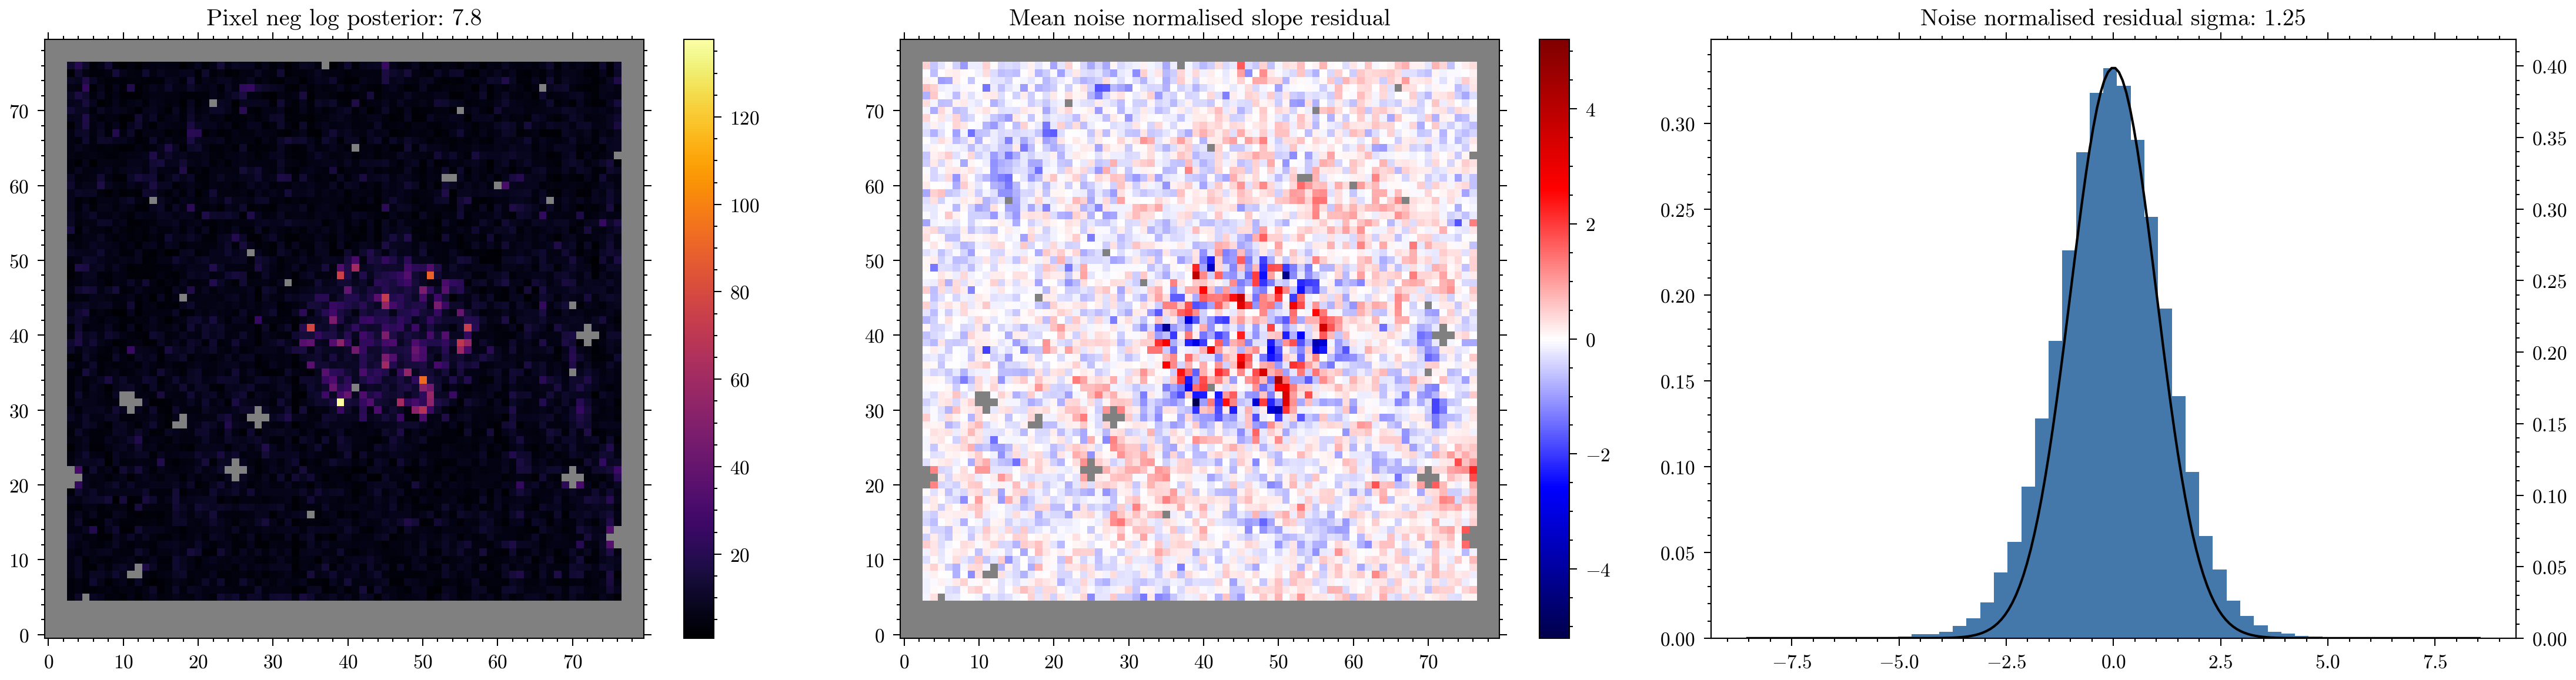

F430M Calibrator TD-CAL-HD-123991 20


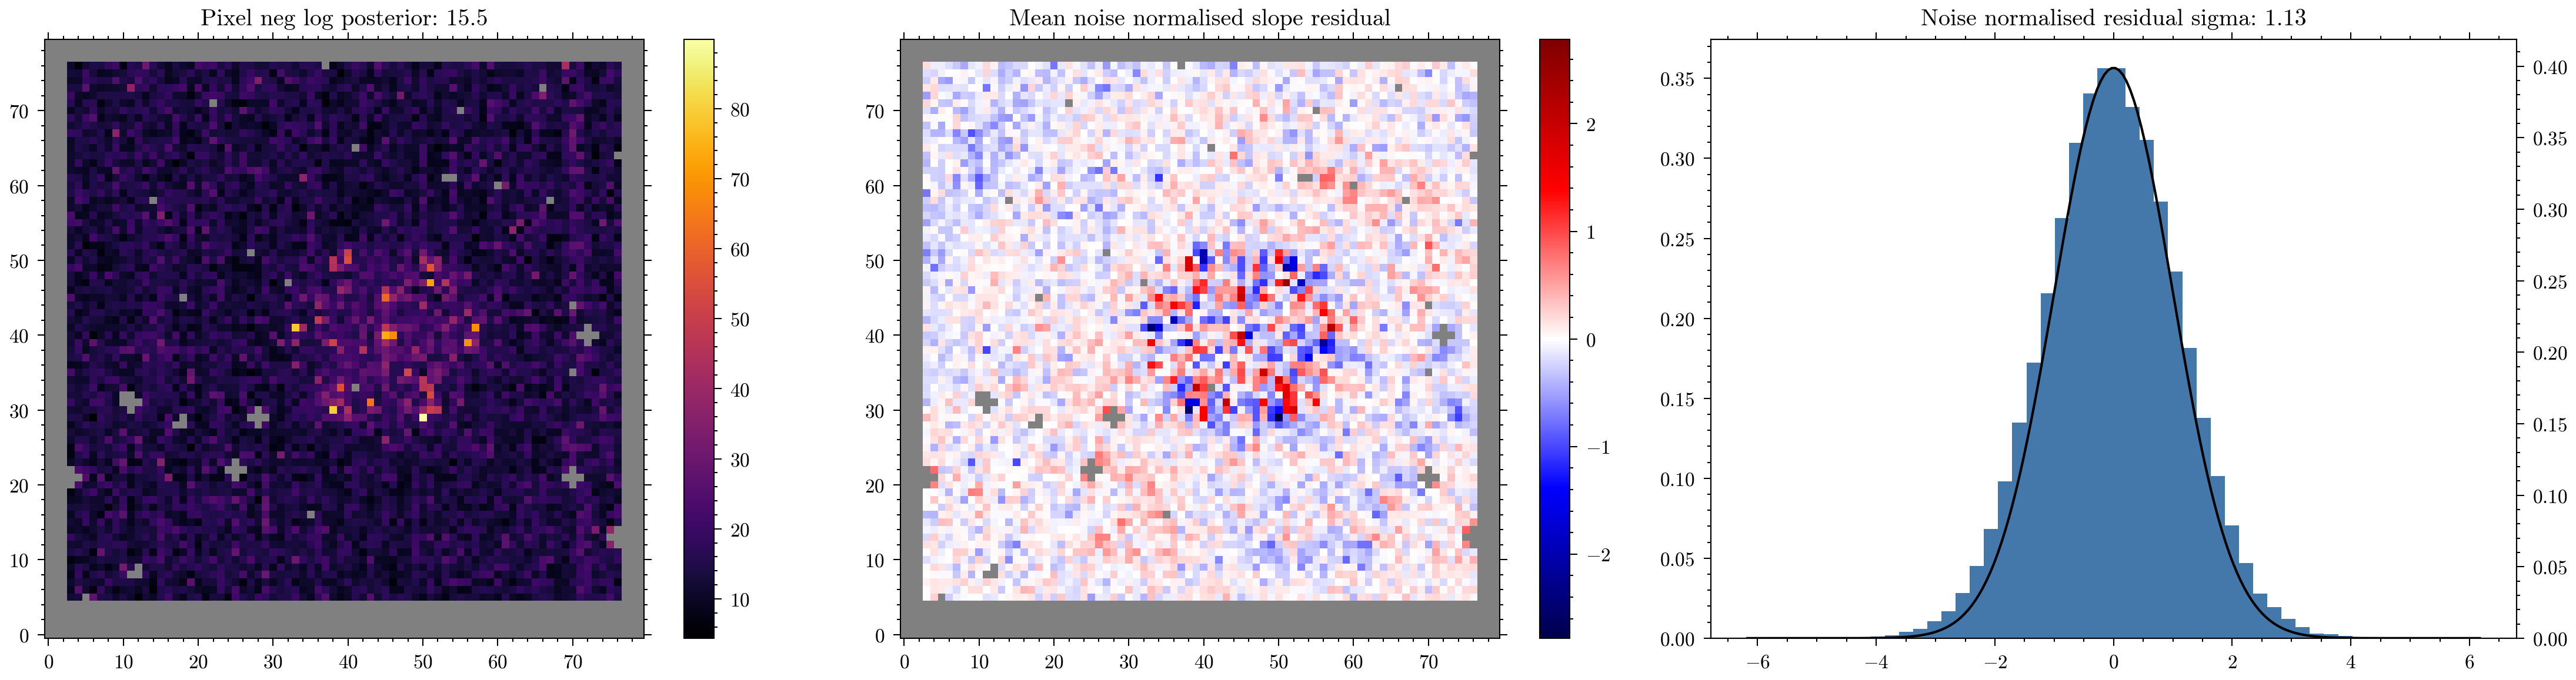

F480M Calibrator TD-CAL-HD-123991 29


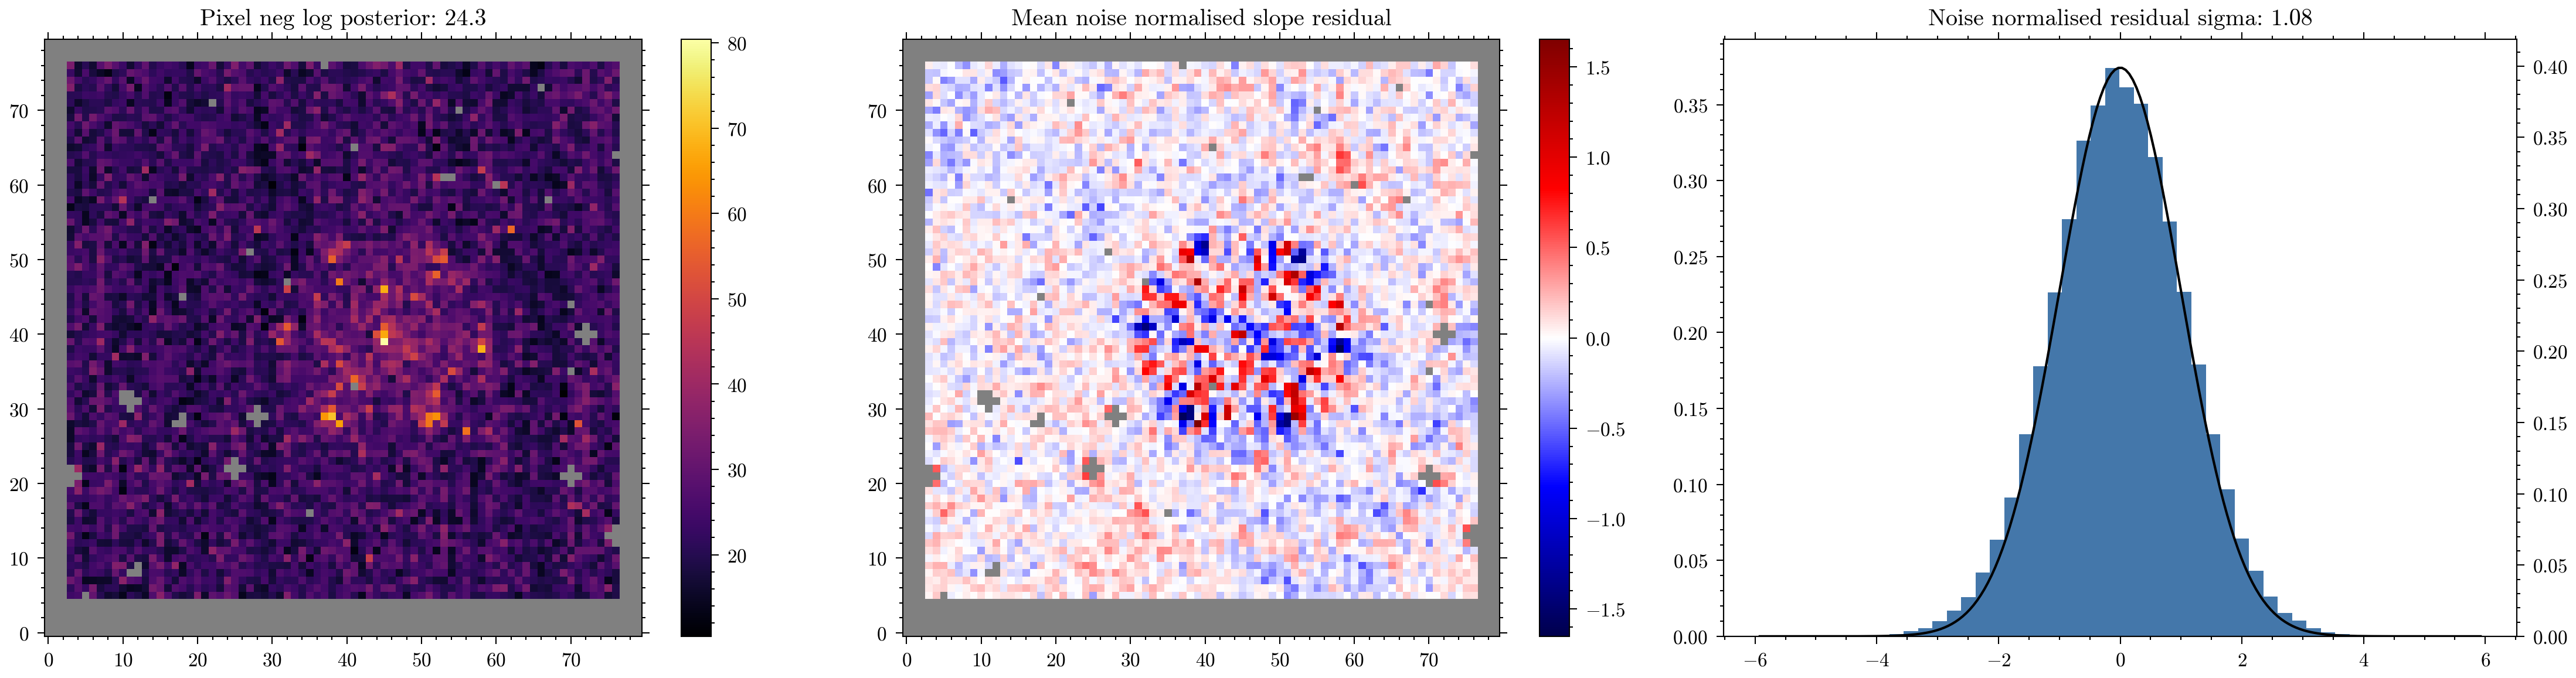

In [ ]:
for filt in ["F380M", "F430M", "F480M"]:
    for exp in exps:
        if exp.filter == filt:
            exp_type = "Calibrator" if exp.calibrator else "Science"
            print(exp.filter, exp_type, exp.star, exp.ngroups)
            amigo.plotting.summarise_fit(final_model, exp)

In [ ]:
# np.save("files/HD135344B_CALFIT.npy", final_model.params, allow_pickle=True)